### SECTION 1 — Setup & Data Loading

In [133]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../data/nhs_waiting_times.csv")

# check data structure
# print(df.shape)
# print(df.columns[:20])

## Section 2 - Exploration of the dataset 

### 2.1 Dataset Overview

The dataset contains NHS Referral to Treatment (RTT) waiting time information, broken down by provider organisation, commissioning organisation, treatment specialty, and waiting-time bands.
The data is stored in a wide format, where each row represents waiting list counts for a provider, treatment type, and time period, broken down by waiting time bands.

The data frame consists of 121 columns including 105 bucket columns representing called "Gt A To B Weeks SUM 1" representing the number of patients whose waiting time for a consultant-led elective treatment is Greater than A weeks but B weeks or less. The remaining 16 columns include information on time period, provider, commissioner, and treatment function. 

In [134]:
df["Period"].unique()
df = df.drop(columns=["Period"])

The period column only contains RTT-February-2026, so it doesn't provide any useful information for analysis. We can drop it from the dataset.

### 2.2 Identify variable groups
The variables can broadly be divided into:
- Identifier variables (provider, commissioner, treatment function)
- Reporting variables (totals and unknown clock starts)
- Waiting-time distribution variables (weekly waiting buckets)

Some columns are repeats (for example, `Treatment function code` is equivalent to `Treatment function name`).

Each row represents waiting-time counts for a specific provider, commissioner, treatment specialty and RTT pathway category with patients distributed across weekly waiting-time bands.

The dataset contains over 100 waiting-time bucket variables. These columns are isolated programmatically (as `wait_cols`) for downstream aggregation and validation.


In [135]:
identifier_cols = [
    "Provider Parent Name",
    "Provider Org Name",
    "Commissioner Parent Name",
    "Commissioner Org Name",
    "Treatment Function Name",
    "RTT Part Description"
]

reporting_cols = [
    "Total",
    "Total All",
    "Patients with unknown clock start date"
]

wait_cols = [c for c in df.columns if "Weeks SUM 1" in c]

print("Identifier columns:", len(identifier_cols))
print("Reporting columns:", len(reporting_cols))
print("Waiting bucket columns:", len(wait_cols))

# Analyse an individual row
df.iloc[0]

Identifier columns: 6
Reporting columns: 3
Waiting bucket columns: 105


Provider Parent Org Code                                                                QE1
Provider Parent Name                      NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...
Provider Org Code                                                                     A4M8P
Provider Org Name                                                         BUCKSHAW HOSPITAL
Commissioner Parent Org Code                                                            NaN
                                                                ...                        
Gt 103 To 104 Weeks SUM 1                                                               0.0
Gt 104 Weeks SUM 1                                                                      0.0
Total                                                                                   NaN
Patients with unknown clock start date                                                  NaN
Total All                                                                       

### 2.3 PROVIDER VS COMMISSIONER
The provider is the organisation delivering care, e.g. Leeds Teaching Hospitals NHS Trust. The commissioner is the organisation funding/commissioning care. We can identify the top providers and commissioners:

In [136]:
df["Provider Org Name"].value_counts().head()
df["Commissioner Org Name"].value_counts().head()

Commissioner Org Name
NHS NORTH WEST LONDON (SUB ICB LOCATION)    4055
NHS NORTH EAST LONDON (SUB ICB LOCATION)    3206
NHS SOUTH WEST LONDON (SUB ICB LOCATION)    3147
NHS KENT AND MEDWAY (SUB ICB LOCATION)      3090
NHS SURREY HEARTLANDS (SUB ICB LOCATION)    3065
Name: count, dtype: int64

## Section 3 - Data Quality Assessment

### 3.1 Missing Value Assessment

Before conducting analysis, the dataset was assessed for potential data quality issues, including missing values and incomplete RTT clock start information.

In [137]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary.head(20)

Patients with unknown clock start date    148166
Total                                     131075
Gt 91 To 92 Weeks SUM 1                    56788
Gt 87 To 88 Weeks SUM 1                    56786
Gt 99 To 100 Weeks SUM 1                   56786
Gt 103 To 104 Weeks SUM 1                  56786
Gt 102 To 103 Weeks SUM 1                  56786
Gt 95 To 96 Weeks SUM 1                    56785
Gt 100 To 101 Weeks SUM 1                  56784
Gt 92 To 93 Weeks SUM 1                    56784
Gt 97 To 98 Weeks SUM 1                    56784
Gt 101 To 102 Weeks SUM 1                  56784
Gt 90 To 91 Weeks SUM 1                    56783
Gt 94 To 95 Weeks SUM 1                    56783
Gt 86 To 87 Weeks SUM 1                    56782
Gt 85 To 86 Weeks SUM 1                    56782
Gt 98 To 99 Weeks SUM 1                    56782
Gt 88 To 89 Weeks SUM 1                    56781
Gt 96 To 97 Weeks SUM 1                    56781
Gt 82 To 83 Weeks SUM 1                    56780
dtype: int64

The waiting-time bucket columns are summed to reconstruct pathway totals for validation purposes.

In [138]:
df["reconstructed_total"] = (
    df[wait_cols]
    .sum(axis=1)
)

The dataset distinguishes between patients with known RTT clock start dates (`Total`), patients with unknown clock start dates, and overall totals (`Total All`). This structure is validated below:

In [139]:
df["all_difference"] = (
    (
        df["Total"] +
        df["Patients with unknown clock start date"]
    )
    -
    df["Total All"]
)


df["all_difference"].describe()

count    33067.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: all_difference, dtype: float64

The dataset distinguishes between pathways with known RTT clock start dates (`Total`) and pathways with unresolved or unknown clock starts. `Total All` therefore provides the most complete patient count and acts as the authoritative total across observations.

Coverage metrics are introduced to assess whether reconstructed totals fully explain reported totals.

In [140]:
df["bucket_coverage_known"] = (
    df["reconstructed_total"] /
    df["Total"]
)
df["bucket_coverage_known"].describe()

count    50140.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: bucket_coverage_known, dtype: float64

The proportion of missing waiting-time bucket values is calculated for each row.

In [141]:
df["missing_bucket_count"] = (
    df[wait_cols]
    .isna()
    .sum(axis=1)
)


df["missing_bucket_rate"] = (
    df["missing_bucket_count"] /
    len(wait_cols)
)
df["missing_bucket_rate"].describe()

count    181233.000000
mean          0.299866
std           0.449328
min           0.000000
25%           0.000000
50%           0.000000
75%           0.980952
max           1.000000
Name: missing_bucket_rate, dtype: float64

The above shows that at least half the rows have NO missing bucket values, but a large chunk of rows have almost ALL bucket values missing. That suggests one of three things:
- some rows are effectively empty/sparse
- represent aggregate/administrative rows
- contain non-applicable combinations

Since median = 0 and upper quartile ≈ 1, this suggests the missing data is probably bimodal. Hence, we need to investigate the sparse rows. 

In [142]:
high_missing = df[df["missing_bucket_rate"] > 0.9]
high_missing[[
    "Provider Org Name",
    "Treatment Function Name",
    "RTT Part Description",
    "Total",
    "Total All"
]].head(20)

,Provider Org Name,Treatment Function Name,RTT Part Description,Total,Total All
25,BUCKSHAW HOSPITAL,General Surgery Service,New RTT Periods - All Patients,NaN,5
26,BUCKSHAW HOSPITAL,Trauma and Orthopaedic Service,New RTT Periods - All Patients,NaN,1
27,BUCKSHAW HOSPITAL,Ear Nose and Throat Service,New RTT Periods - All Patients,NaN,4
28,BUCKSHAW HOSPITAL,Total,New RTT Periods - All Patients,NaN,10
40,BUCKSHAW HOSPITAL,General Surgery Service,New RTT Periods - All Patients,NaN,6
41,BUCKSHAW HOSPITAL,Ear Nose and Throat Service,New RTT Periods - All Patients,NaN,6
42,BUCKSHAW HOSPITAL,Gastroenterology Service,New RTT Periods - All Patients,NaN,1
43,BUCKSHAW HOSPITAL,Gynaecology Service,New RTT Periods - All Patients,NaN,2
44,BUCKSHAW HOSPITAL,Total,New RTT Periods - All Patients,NaN,15
71,BUCKSHAW HOSPITAL,General Surgery Service,New RTT Periods - All Patients,NaN,95


A subset of rows exhibited extremely high bucket-level missingness, often corresponding to sparse or inactive reporting combinations. To ensure robust downstream analysis, observations with poor coverage or zero reported totals were excluded from the analytical subset (this is set at the end).

### 3.2 Understand unknown clock starts
The column "Total Patients with unknown clock start date" represents the number of patients on an RTT pathway (waiting for treatment) where the trust cannot identify the precise date the RTT clock started, often due to administrative issues or delays in receiving referral information. This usually indicates a data quality issue or a failed Inter Provider Transfer (IPT). Hence, I will create a data quality metric quantifying this situation. 

In [159]:
df["Patients with unknown clock start date"].count()
df["unknown_clock_rate"] = (
    df["Patients with unknown clock start date"] /
    df["Total All"]
)

Where official totals are missing, totals are reconstructed using the sum of constituent waiting-time buckets.
This preserves internal consistency while minimising unnecessary row removal.

In [160]:
df["Total"] = df["Total"].fillna(
    df["reconstructed_total"]
)

We can use this metric to find which providers may have poorer reporting quality, operational variation or possible system issues

In [161]:
provider_quality = (
    df.groupby("Provider Org Name")["unknown_clock_rate"]
    .mean()
    .sort_values(ascending=False)
)

provider_quality.head(10)

Provider Org Name
WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDATION TRUST          0.102185
GREAT ORMOND STREET HOSPITAL FOR CHILDREN NHS FOUNDATION TRUST    0.090890
UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST                           0.014786
UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST                  0.012565
ROYAL SURREY NHS FOUNDATION TRUST                                 0.007625
ROYAL FREE LONDON NHS FOUNDATION TRUST                            0.000465
MID AND SOUTH ESSEX NHS FOUNDATION TRUST                          0.000444
OVIVA UK LTD                                                      0.000412
NORTH WEST ANGLIA NHS FOUNDATION TRUST                            0.000401
LEEDS TEACHING HOSPITALS NHS TRUST                                0.000081
Name: unknown_clock_rate, dtype: float64

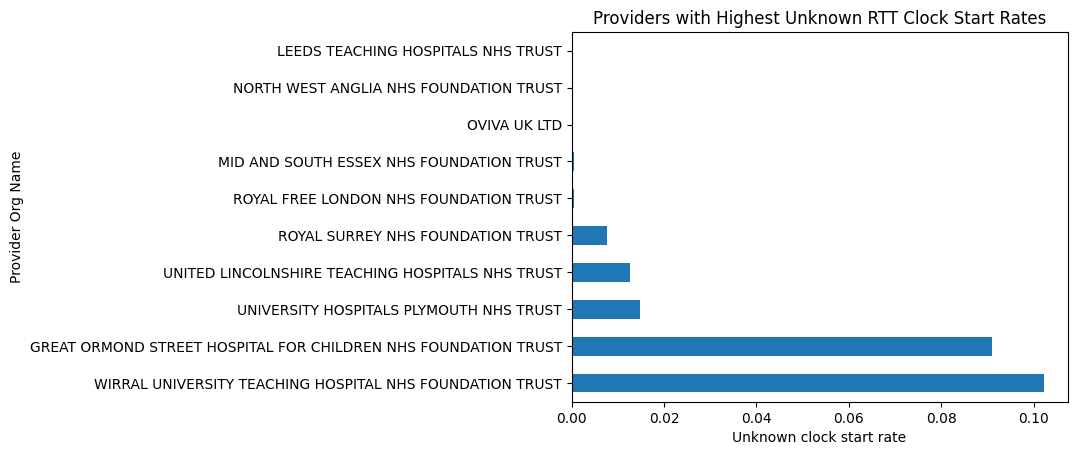

In [162]:
provider_quality.head(10).plot(kind="barh")

plt.title("Providers with Highest Unknown RTT Clock Start Rates")
plt.xlabel("Unknown clock start rate")
plt.show()

### 3.3 Check total consistency
Now verify whether bucket sums align with totals.

In [163]:
wait_cols = [c for c in df.columns if "Weeks SUM 1" in c]
df["calculated_total"] = df[wait_cols].sum(axis=1)
(
    df["calculated_total"] -
    df["Total"]
).unique() # Shows that the calculated total matches the reported total for all rows, confirming that the waiting bucket columns sum to the total column.

array([0.])

Rows with zero activity are removed from the analysis dataframe.

In [164]:
analysis_df = df[
    df["Total All"] > 0
].copy()

### 3.4 Summary of findings
Rather than removing incomplete records, missing total waiting-time values were derived from the sum of the constituent waiting-time buckets. This leveraged the hierarchical structure of the dataset and reduced avoidable data loss while maintaining consistency with the reporting framework. Variation also exists in the proportion of patients with unknown RTT clock start dates across providers, suggesting differences in referral tracking and data quality processes.

## 4. Waiting-Time Distribution Engineering
The goal of this section is to find meaningful summary features, interpretable clinical metrics and analysis-ready variables from the available data. The data set contains a large number of waiting-time bucket variables representing counts of patients within week-long periods. Each column represents a discrete waiting-time interval (e.g. 0–1 weeks, 1–2 weeks, etc.), forming a histogram-like representation of the waiting-time distribution.

In [165]:
# wait_cols = [c for c in df.columns if "Weeks SUM 1" in c]

# len(wait_cols)
analysis_df[wait_cols] = analysis_df[wait_cols].apply(pd.to_numeric, errors="coerce") # ensure entries are in numeric format, coercing non-numeric entries to NaN
analysis_df.head(10)

,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,RTT Part Description,...,Patients with unknown clock start date,Total All,reconstructed_total,all_difference,bucket_coverage_known,missing_bucket_count,missing_bucket_rate,unknown_rate,calculated_total,unknown_clock_rate
0,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,Incomplete Pathways,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
1,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,13Q,NATIONAL COMMISSIONING HUB 1,Part_2,Incomplete Pathways,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
2,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,Incomplete Pathways,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
3,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,Incomplete Pathways,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
4,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2,Incomplete Pathways,...,NaN,2,2.0,NaN,NaN,0,0.0,NaN,2.0,NaN
5,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2A,Incomplete Pathways with DTA,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
6,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,NaN,NaN,Y62,NaN,Part_2A,Incomplete Pathways with DTA,...,NaN,1,1.0,NaN,NaN,0,0.0,NaN,1.0,NaN
7,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1A,Completed Pathways For Admitted Patients,...,0.0,1,1.0,0.0,1.0,0,0.0,0.0,1.0,0.0
8,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1A,Completed Pathways For Admitted Patients,...,0.0,1,1.0,0.0,1.0,0,0.0,0.0,1.0,0.0
9,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1B,Completed Pathways For Non-Admitted Patients,...,0.0,7,7.0,0.0,1.0,0,0.0,0.0,7.0,0.0


We can collapse buckets into interpretable groups: 
- short waits (0-18 weeks)
- medium waits (19-52 weeks)
- long waits (53-78 weeks)
- very long waits (78+ weeks)

These are overlapping categories rather than mutually exclusive groups.

Aggregation of waiting-time buckets into clinically meaningful groups to enables clearer interpretation of waiting-time severity and to supports comparative analysis across providers and specialties.

Feature columns were constructed using batch concatenation to improve computational efficiency and avoid DataFrame fragmentation during iterative column assignment.

In [166]:
# Create meaningful waiting time buckets
short_wait_cols = wait_cols[:18]
medium_wait_cols = wait_cols[18:52]
long_wait_cols = wait_cols[52:78]
very_long_wait_cols = wait_cols[78:]

In [167]:
analysis_df = analysis_df.copy()

analysis_df["short_wait"] = analysis_df[short_wait_cols].sum(axis=1)
analysis_df["medium_wait"] = analysis_df[medium_wait_cols].sum(axis=1)
analysis_df["long_wait"] = analysis_df[long_wait_cols].sum(axis=1)
analysis_df["very_long_wait"] = analysis_df[very_long_wait_cols].sum(axis=1)

In [168]:
analysis_df["wait_18_plus"] = (
    analysis_df[medium_wait_cols + long_wait_cols + very_long_wait_cols]
    .sum(axis=1)
)

analysis_df["wait_52_plus"] = (
    analysis_df[long_wait_cols + very_long_wait_cols]
    .sum(axis=1)
)

analysis_df["wait_78_plus"] = (
    analysis_df[very_long_wait_cols]
    .sum(axis=1)
)

In [169]:
# Sanity checks
df["reconstructed_total"] = df[wait_cols].sum(axis=1)
(df["reconstructed_total"] - df["Total"]).unique()
# The above contains only zeros, confirming that the waiting bucket columns sum to the total column.

array([0.])

Reconstructed totals were compared against reported totals to validate the integrity of the transformation process.

Note that the above waiting-time threshold metrics (18+, 52+, and 78+ weeks) are cumulative measures rather than mutually exclusive categories. For example, patients waiting over 52 weeks are also included within the 18+ week group. We could also analyse mutually exclusive bins.

Rates are normalised by the total number of known RTT pathways.

In [170]:
analysis_df["rate_18_plus"] = (
    analysis_df["wait_18_plus"] /
    analysis_df["Total"]
)

analysis_df["rate_52_plus"] = (
    analysis_df["wait_52_plus"] /
    analysis_df["Total"]
)

analysis_df["rate_78_plus"] = (
    analysis_df["wait_78_plus"] /
    analysis_df["Total"]
)

In [171]:
analysis_df[[
    "rate_18_plus",
    "rate_52_plus",
    "rate_78_plus"
]].describe()

,rate_18_plus,rate_52_plus,rate_78_plus
count,145344.000000,145344.000000,145344.000000
mean,0.406186,0.043186,0.001471
std,0.379261,0.160449,0.029368
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.343561,0.000000,0.000000
75%,0.666667,0.000000,0.000000
max,1.000000,1.000000,1.000000


## 5. AGGREGATION & STRUCTURED ANALYSIS
We now want to use group-level analysis to answer where the biggest waiting time pressures are, and how they vary across providers, commissioners, and specialties. The following key performance indicators (constructed in section 4) are used to assess waiting time pressure:
- 18+ week waits (NHS operational target threshold)
- 52+ week waits (long-term backlog indicator)
- 78+ week waits (extreme delay indicator)

In [172]:
provider_summary = (
    analysis_df
    .groupby("Provider Org Name")
    [[
        "rate_18_plus",
        "rate_52_plus",
        "rate_78_plus",
        "Total"
    ]]
    .mean()
    .sort_values("rate_52_plus", ascending=False)
)

provider_summary.head(10)

,rate_18_plus,rate_52_plus,rate_78_plus,Total
Provider Org Name,,,,
OXLEAS NHS FOUNDATION TRUST,0.668211,0.342062,0.000000,210.400000
BESPOKE HEALTHCARE LTD,0.563865,0.299058,0.000000,174.000000
"NUFFIELD HEALTH, EXETER HOSPITAL",0.602334,0.272219,0.144761,68.173913
PIONEER HEALTHCARE LIMITED,0.480406,0.261707,0.013451,18.549451
SPIRE LEICESTER HOSPITAL,0.566523,0.216008,0.007246,52.035088
"NUFFIELD HEALTH, GUILDFORD HOSPITAL",0.600893,0.201154,0.105077,4.068966
LIVERPOOL WOMEN'S NHS FOUNDATION TRUST,0.542009,0.163208,0.000013,80.356828
CHESTERFIELD ROYAL HOSPITAL NHS FOUNDATION TRUST,0.523541,0.143212,0.000004,136.305026
"NUFFIELD HEALTH, TAUNTON HOSPITAL",0.716335,0.142732,0.000000,59.629630


We can also compare the waiting times across treatment specialities.

In [173]:
specialty_summary = (
    analysis_df
    .groupby("Treatment Function Name")
    [[
        "rate_18_plus",
        "rate_52_plus",
        "rate_78_plus"
    ]]
    .mean()
    .sort_values("rate_52_plus", ascending=False)
)

specialty_summary.head(10)

,rate_18_plus,rate_52_plus,rate_78_plus
Treatment Function Name,,,
Ear Nose and Throat Service,0.542650,0.088809,0.002146
Gynaecology Service,0.516592,0.072622,0.000858
Plastic Surgery Service,0.490818,0.069714,0.002904
Oral Surgery Service,0.542164,0.067880,0.000384
Trauma and Orthopaedic Service,0.470990,0.051207,0.002752
Other - Surgical Services,0.401698,0.048361,0.001153
General Surgery Service,0.419637,0.048351,0.001448
Urology Service,0.414306,0.045567,0.000618
Total,0.403227,0.045011,0.001657


Finally, we can explore the correlation between reporting quality and waiting-time outcomes:

In [174]:
analysis_df[[
    "missing_bucket_rate",
    "unknown_clock_rate",
    "rate_52_plus"
]].corr()

,missing_bucket_rate,unknown_clock_rate,rate_52_plus
missing_bucket_rate,1.000000,-0.004521,-0.006520
unknown_clock_rate,-0.004521,1.000000,0.000588
rate_52_plus,-0.006520,0.000588,1.000000
